# Decision Trees

How does a model arrive at a decision the same way you'd win a game of *20 Questions*? **Decision trees** ask one simple yes/no question at a time, and after a handful of questions they commit to an answer.

A **decision tree** is a supervised learning algorithm that learns a hierarchy of simple if-then-else rules from data. The deeper the tree, the more detailed the rules and the more closely the model fits the training data.

In this lesson we learn to:

- Fit a `DecisionTreeClassifier` on the **Iris** flowers dataset
- Read **leaf probabilities** as class fractions
- Visualize a fitted tree with `plot_tree`
- Draw the **decision boundaries** a tree carves out in feature space
- Recognize **overfitting** and control it with `min_samples_leaf`

In [1]:
# https://matplotlib.org/stable/
import matplotlib.pyplot as plt

# https://matplotlib.org/stable/api/_as_gen/matplotlib.colors.ListedColormap.html
from matplotlib.colors import ListedColormap

# https://numpy.org/doc/stable/
import numpy as np

# https://pandas.pydata.org/docs/
import pandas as pd

# https://seaborn.pydata.org/
import seaborn as sns

# https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html
from sklearn.datasets import load_iris

# https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html
from sklearn.datasets import make_moons

# https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
from sklearn.tree import DecisionTreeClassifier

# https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html
from sklearn.tree import plot_tree

## 1. Load the Iris dataset

The **Iris** dataset is a classic classification problem:

- **Features:** four flower measurements (sepal length/width, petal length/width), all in centimetres.
- **Target:** the iris **species** — `setosa`, `versicolor`, or `virginica`.

![Figure: Iris Flowers Dataset](../assets/iris_flowers.png)

In [2]:
iris = load_iris(as_frame=True)  # return the data as a pandas DataFrame

# Show the features and the target side by side
pd.concat([iris.data, iris.target], axis=1)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


## 2. Fit a decision tree classifier

To keep the decision boundaries easy to draw later, we train on just the **two petal features**, which separate the species well.

We cap the tree at `max_depth=2`, so it can ask at most two questions before predicting.

In [3]:
feature_cols = ["petal length (cm)", "petal width (cm)"]

# Keep only the two petal features, as plain NumPy arrays for the grid plots below
X_iris = iris.data[feature_cols].values
y_iris = iris.target.values

tree_clf = DecisionTreeClassifier(
    max_depth=2,  # at most two questions from root to leaf
    random_state=42,  # reproducible splits
)
tree_clf.fit(X_iris, y_iris)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

Once fitted, the tree can predict the species of a new flower. We pass a sample with a petal length of 5 cm and a petal width of 1.5 cm:

In [4]:
sample = [[5.0, 1.5]]  # [petal length (cm), petal width (cm)]

predicted_class = tree_clf.predict(sample)
iris.target_names[predicted_class]

array(['versicolor'], dtype='<U10')

The tree can also report a **probability** for each class. For a decision tree, this is simply **the fraction of training samples of each class in the leaf** the sample lands in:

In [5]:
probabilities = tree_clf.predict_proba(sample).round(3)

# Pair each probability with its species name for readability
pd.Series(probabilities[0], index=iris.target_names)

setosa        0.000
versicolor    0.907
virginica     0.093
dtype: float64

The three numbers are $P(\text{setosa})$, $P(\text{versicolor})$, and $P(\text{virginica})$. They sum to 1, and every flower that reaches the same leaf gets the **same** probabilities.

## 3. Visualize the tree

`plot_tree` draws the fitted rules. Each node shows its split question, the number of training samples reaching it, and the class counts; the colour encodes the majority class.

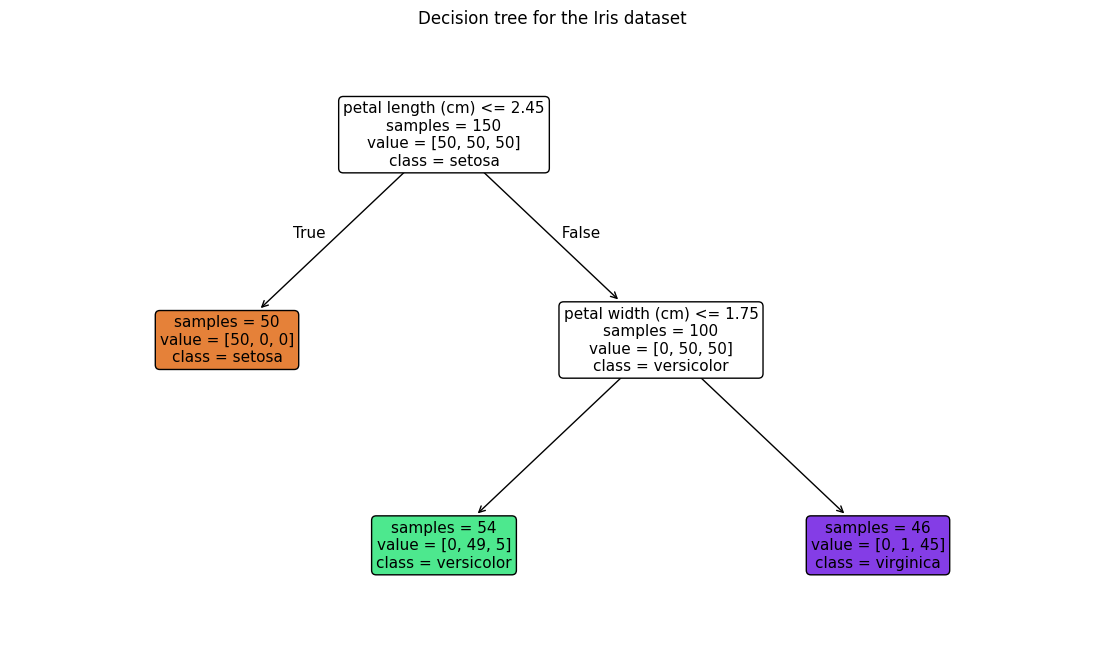

In [6]:
fig, ax = plt.subplots(figsize=(14, 8))

plot_tree(
    tree_clf,
    feature_names=feature_cols,  # label the split questions with feature names
    class_names=iris.target_names,  # label the leaves with species names
    filled=True,  # colour nodes by majority class
    rounded=True,  # rounded node boxes
    impurity=False,  # hide the Gini impurity to reduce clutter
    fontsize=11,
    ax=ax,
)
ax.set_title("Decision tree for the Iris dataset")

plt.show()

## 4. Decision boundaries

Because each split compares **one feature** to **one threshold**, a tree carves the feature space into **axis-aligned rectangles**. Every rectangle (leaf) is assigned a single class.

The helper below predicts the class for every point on a fine grid, then paints each region with the predicted colour.

In [7]:
def plot_decision_boundary(clf, X, y, ax, class_names, region_cmap):
    """Shade the regions a fitted classifier assigns to each class."""
    # Build a grid that spans the data with a small margin
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200),
    )

    # Predict the class for every grid point, reshaped back to the grid
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    predictions = clf.predict(grid_points).reshape(xx.shape)

    # Paint the predicted regions, then overlay the training points
    ax.contourf(xx, yy, predictions, alpha=0.3, cmap=region_cmap)
    sns.scatterplot(
        x=X[:, 0],
        y=X[:, 1],
        hue=[class_names[label] for label in y],  # colour points by true class
        style=[class_names[label] for label in y],  # vary marker by class too
        palette="dark",
        ax=ax,
    )

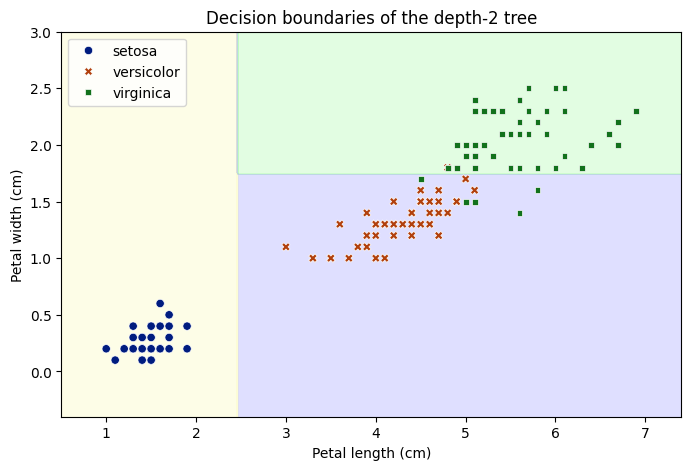

In [8]:
iris_cmap = ListedColormap(["#fafab0", "#9898ff", "#a0faa0"])

fig, ax = plt.subplots(figsize=(8, 5))

plot_decision_boundary(
    tree_clf,
    X_iris,
    y_iris,
    ax=ax,
    class_names=iris.target_names,
    region_cmap=iris_cmap,
)
ax.set_xlabel("Petal length (cm)")
ax.set_ylabel("Petal width (cm)")
ax.set_title("Decision boundaries of the depth-2 tree")

plt.show()

The boundaries are straight, horizontal or vertical cuts — never diagonals or curves. This is the signature of a decision tree: it splits on **one feature at a time**.

## 5. Avoid overfitting

Decision trees **tend to overfit** when the samples-to-features ratio is small. Left unrestricted, a tree keeps growing branches until it has **a specific rule for every single training point**.

In scikit-learn, restricting a tree so it does not memorize the training data is called **regularization** or **pruning**. The two most immediate controls are:

- **`max_depth`** — the maximum number of questions from root to leaf.
- **`min_samples_leaf`** — the minimum number of training samples a leaf must hold.

Let's illustrate the problem on the two-moons dataset.

In [9]:
X_moons, y_moons = make_moons(
    n_samples=150,
    noise=0.2,  # scatter the points so the classes overlap a little
    random_state=42,
)

# An unrestricted tree vs. one that requires at least 5 samples per leaf
tree_unrestricted = DecisionTreeClassifier(random_state=42)
tree_pruned = DecisionTreeClassifier(min_samples_leaf=5, random_state=42)

tree_unrestricted.fit(X_moons, y_moons)
tree_pruned.fit(X_moons, y_moons)

,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

Plotting the two side by side shows the effect of `min_samples_leaf=5`:

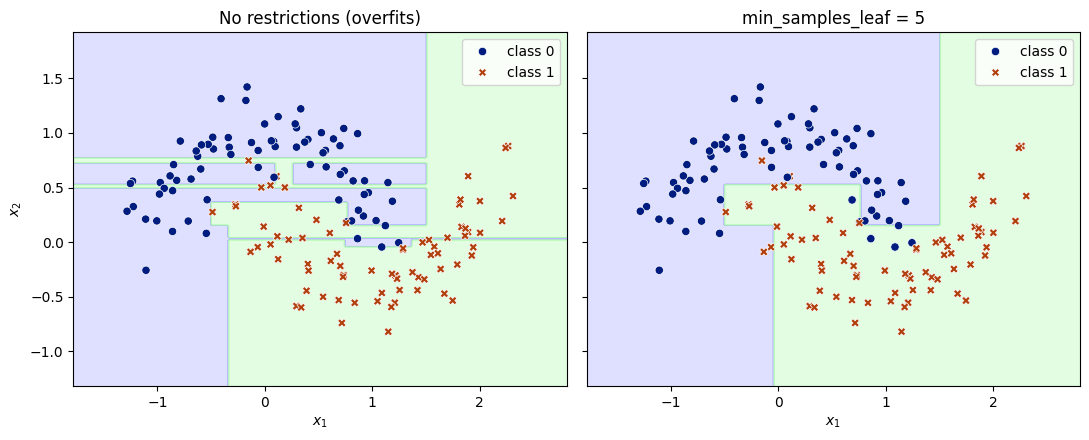

In [10]:
moons_cmap = ListedColormap(["#9898ff", "#a0faa0"])
moons_classes = np.array(["class 0", "class 1"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

plot_decision_boundary(
    tree_unrestricted,
    X_moons,
    y_moons,
    ax=axes[0],
    class_names=moons_classes,
    region_cmap=moons_cmap,
)
axes[0].set_title("No restrictions (overfits)")
axes[0].set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")

plot_decision_boundary(
    tree_pruned,
    X_moons,
    y_moons,
    ax=axes[1],
    class_names=moons_classes,
    region_cmap=moons_cmap,
)
axes[1].set_title("min_samples_leaf = 5")
axes[1].set_xlabel("$x_1$")

fig.tight_layout()
plt.show()

- **Left:** the unrestricted tree contorts its boundary around individual noisy points — it **memorizes** the training set.
- **Right:** requiring at least 5 samples per leaf yields a smoother boundary that should **generalize** better to new flowers.

## Recap

- A decision tree learns a **hierarchy of yes/no rules**, each comparing one feature to one threshold.
- **Leaf probabilities** are the fraction of training samples of each class in the leaf.
- Decision boundaries are **axis-aligned rectangles** — no diagonals or curves.
- Unrestricted trees **overfit**; `max_depth` and `min_samples_leaf` control the trade-off.

## References

- [Decision Trees — scikit-learn User Guide](https://scikit-learn.org/stable/modules/tree.html)
- [DecisionTreeClassifier API](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)
- [plot_tree API](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html)